**Module 2 homework 4**

In [ ]:
import pandas as pd
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
print('Shape:', df.shape)


Shape: (7043, 21)


Rows: 7043  Columns: 21

In [ ]:
df.head()
# shows first 10 rows of the data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Shows the dtypes of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


They are two data types: object and float64

In [ ]:
df.describe().round(2)
# Gives statistical info about data

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76,2279.73
std,0.37,24.56,30.09,2266.79
min,0.00,0.00,18.25,0.00
25%,0.00,9.00,35.50,398.55
50%,0.00,29.00,70.35,1394.55
75%,0.00,55.00,89.85,3786.60
max,1.00,72.00,118.75,8684.80


In [ ]:
# Show how many unique values are in each column.
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [ ]:
# Keep only rows where MonthlyCharges > 80
high_pay = df[df['MonthlyCharges'] > 80]
print('High-paying customers:', len(high_pay))
high_pay.head()

High-paying customers: 2666


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
12,8091-TTVAX,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,No,Credit card (automatic),100.35,5681.10,No
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes


2666 customers pay more than 80

In [ ]:
# Sort by tenure descending and take the first 10 rows.
top10 = df.sort_values('tenure', ascending=False).head(10)
top10[['customerID', 'tenure', 'Contract', 'MonthlyCharges']]

,customerID,tenure,Contract,MonthlyCharges
3177,1814-WFGVS,72,Two year,48.90
3131,8336-TAVKX,72,Two year,78.45
3107,5038-ETMLM,72,Two year,113.65
35,6234-RAAPL,72,Two year,99.90
3111,8809-RIHDD,72,Two year,103.40
3112,8809-XKHMD,72,Two year,100.55
3203,5879-HMFFH,72,Two year,88.05
3205,3810-DVDQQ,72,Two year,117.60
3247,8853-TZDGH,72,Two year,111.60
3266,0464-WJTKO,72,Two year,20.10


The longest-tenured customers have been with the company for 72 months (6 years), and most of them are on two-year contracts.

In [ ]:
# Group by PaymentMethod and compute mean MonthlyCharges.
df.groupby('PaymentMethod')['MonthlyCharges'].mean().round(2)

,MonthlyCharges
PaymentMethod,
Bank transfer (automatic),67.19
Credit card (automatic),66.51
Electronic check,76.26
Mailed check,43.92


The average monthly charge varies by payment method. Customers using electronic checks pay the most on average ($76.26), while those using mailed checks pay the least (43.92). Automatic payment methods fall in between, with average monthly charges of approximately 66–67 dollars.

In [ ]:
# Group by Churn and compute mean AND count of TotalCharges.
df.groupby('Churn')['TotalCharges'].agg(['mean', 'count']).round(2)

,mean,count
Churn,,
No,2549.91,5174
Yes,1531.80,1869


In [ ]:
# Group by Churn and compute mean AND count of TotalCharges.
df.groupby('Churn').agg({'TotalCharges': ['mean', 'count']}).round(2)

TotalCharges      
              mean count
Churn                   
No         2549.91  5174
Yes        1531.80  1869

In [ ]:
pd.crosstab(df['Contract'], df['Churn'])
# Churn = Yes → the customer left/cancelled the service
# Churn = No → the customer stayed with the company

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


For customers on a month-to-month contract, 2,220 customers stayed with the company, while 1,655 customers left (churned). In contrast, among customers with a two-year contract, 1,647 customers stayed, while only 48 customers left.

**Module 2 Homework 5**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

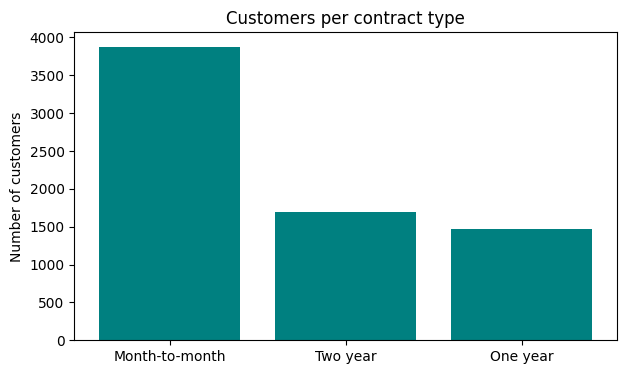

In [ ]:
# How many customers have each Contract type

counts = df['Contract'].value_counts()
plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values, color='teal')
plt.title('Customers per contract type')
plt.ylabel('Number of customers')
plt.show()

Most of the customers choose month-to-month Contract type.

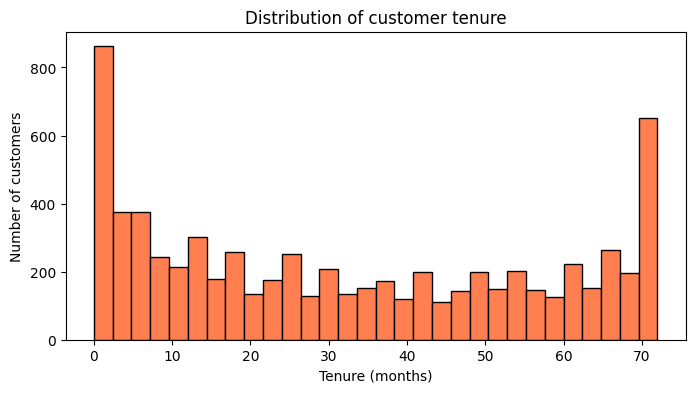

In [ ]:
# The number of customers by tenure (month)

plt.figure(figsize=(8, 4))
plt.hist(df['tenure'], bins=30, color='coral', edgecolor='black')
plt.title('Distribution of customer tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of customers')
plt.show()

More than 800 customers new to the company, while more than 600 are old clients.

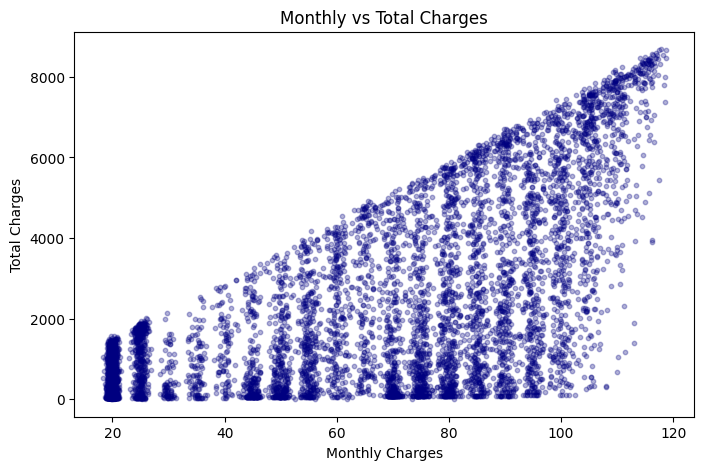

In [ ]:
# A scatter plot of MonthlyCharges (x) vs TotalCharges (y)

plt.figure(figsize=(8, 5))
plt.scatter(df['MonthlyCharges'], df['TotalCharges'], alpha=0.3, s=10, color='navy')
plt.title('Monthly vs Total Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Total Charges')
plt.show()

A scatter showing positive correlation — higher monthly charges = higher total charges.

/tmp/ipykernel_740/2180416385.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


<function matplotlib.pyplot.show(close=None, block=None)>

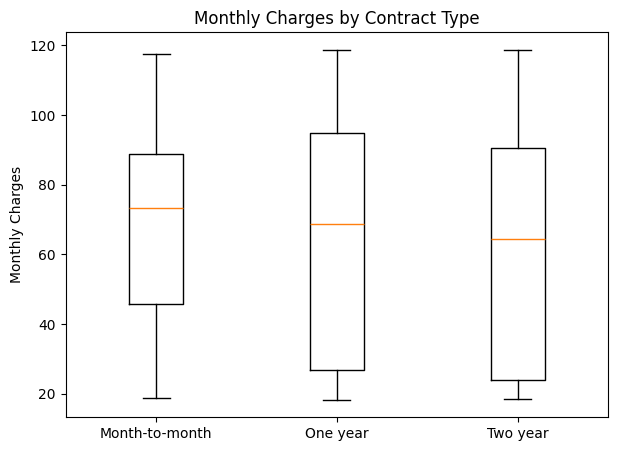

In [ ]:
# Compare Monthly  Charges across 3 Contract types using Box Plot

groups = [df[df['Contract'] == c]['MonthlyCharges']for c in df['Contract'].unique()]
labels = df['Contract'].unique()
plt.figure(figsize=(7, 5))
plt.boxplot(groups, labels=labels)
plt.title('Monthly Charges by Contract Type')
plt.ylabel('Monthly Charges')
plt.show

The distribution of Monthly Charges is wide across all contract types. Customers with one-year contracts show the greatest variability in Monthly Charges, as indicated by the largest interquartile range. Month-to-month customers have the highest median Monthly Charges, while customers with longer-term contracts generally pay slightly lower monthly fees.

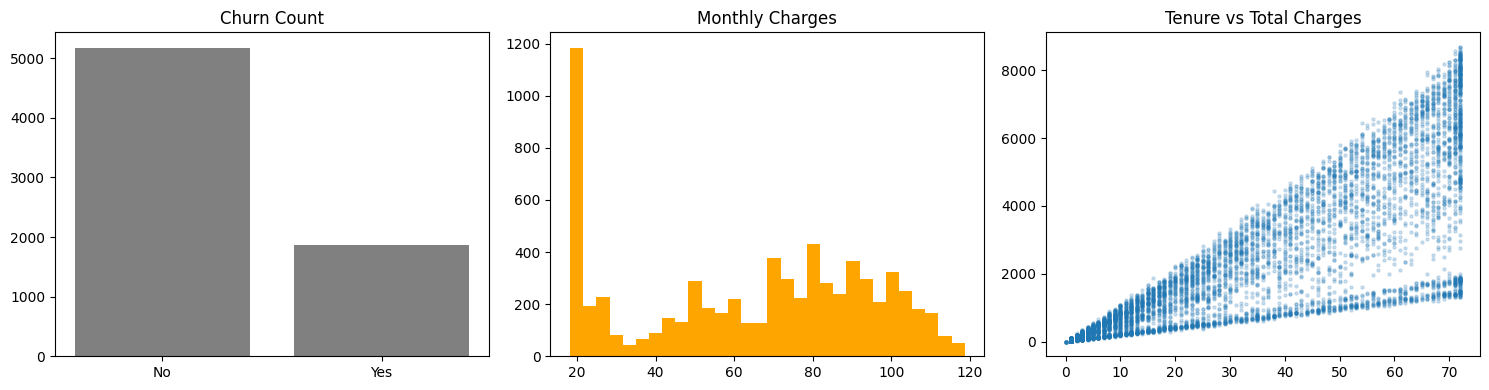

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(df['Churn'].value_counts().index, df['Churn'].value_counts().values, color='gray')
ax[0].set_title('Churn Count')
ax[1].hist(df['MonthlyCharges'], bins=30, color='orange')
ax[1].set_title('Monthly Charges')
ax[2].scatter(df['tenure'], df['TotalCharges'], alpha=0.2, s=5)
ax[2].set_title('Tenure vs Total Charges')
plt.tight_layout()
plt.show()

Conclusion:
1. More than 5000 customers stayed with the company
2. Monthly Charges range from approximately 20 to 120. The highest concentration of customers is around 20–25 per month, indicating many customers subscribe to lower-cost plans. Another notable concentration appears between 70 and 100, suggesting a substantial number of customers purchase additional services. Overall, the distribution is wide, reflecting considerable variation in customer billing amounts.
3. Tenure and Total Charges have a positive correlation. As tenure increases, Total Charges tend to increase as well.